In [24]:
pip install keras opencv-python numpy matplotlib scikit-image


Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import keras
import cv2
import numpy
import matplotlib
import skimage

from keras.models import Sequential
from keras.layers import Conv2D
from keras.optimizers import Adam

from skimage.metrics import structural_similarity as ssim
from matplotlib import pyplot as plt

import cv2
import numpy as np
import math
import os

In [3]:

def psnr(target, ref):
  target_data = target.astype(float)
  ref_data = ref.astype(float)

  diff = ref_data - target_data
  diff = diff.flatten('C')

  rmse = math.sqrt(np.mean(diff ** 2.))

  return 20 * math.log10(255. / rmse)

def mse(target, ref):
  err = np.sum((target.astype(float) - ref.astype(float)) ** 2)
  err /= float(target.shape[0] * target.shape[1])

  return err

def compare_images(target, ref):
  scores = []
  scores.append(psnr(target, ref))
  scores.append(mse(target, ref))
  scores.append(ssim(target, ref, channel_axis=-1))

  return scores

In [4]:
cwd = os.getcwd()
def prepare_images(path, factor):

  for file in os.listdir(path):
    try:
      img = cv2.imread(path + '/' + file)

      h, w, _ =  img.shape
      new_height = int(h / factor)
      new_width = int(w / factor)

      #resize the image - down
      img = cv2.resize(img, (new_width, new_height), interpolation = cv2.INTER_LINEAR)

      #resize the image - up
      img = cv2.resize(img, (w, h), interpolation = cv2.INTER_LINEAR)

      #save the image
      print('Saving {}'.format(file))
      cv2.imwrite('images/{}'.format(file), img)
    except:
      print('ERROR for file - ', file, '!')
      pass

prepare_images('source/', 2)




Saving baboon.bmp
Saving baby_GT.bmp
Saving barbara.bmp
Saving bird_GT.bmp
Saving bridge.bmp
Saving butterfly_GT.bmp
Saving coastguard.bmp
Saving comic.bmp
Saving face.bmp
Saving flowers.bmp
Saving foreman.bmp
Saving head_GT.bmp
Saving lenna.bmp
Saving man.bmp
Saving monarch.bmp
Saving pepper.bmp
Saving ppt3.bmp
Saving woman_GT.bmp
Saving zebra.bmp


In [5]:

for file in os.listdir('images/'):
  try:

    target = cv2.imread('images/{}'.format(file))
    ref = cv2.imread('source/{}'.format(file))

    scores = compare_images(target, ref)
    print('{}\nPSNR: {}\nMSE: {}\nSSIM: {}\n'.format(file, scores[0], scores[1], scores[2]))
  except:
    pass

baboon.bmp
PSNR: 22.157084083442548
MSE: 1187.1161333333334
SSIM: 0.629277587900277

baby_GT.bmp
PSNR: 34.37180640966199
MSE: 71.28874588012695
SSIM: 0.9356987872724932

barbara.bmp
PSNR: 25.906629837568126
MSE: 500.65508535879627
SSIM: 0.8098632646406401

bird_GT.bmp
PSNR: 32.896644728720005
MSE: 100.12375819830247
SSIM: 0.9533644866026473

bridge.bmp
PSNR: 25.850528790115554
MSE: 507.1643714904785
SSIM: 0.7804245912255268

butterfly_GT.bmp
PSNR: 24.782076560337416
MSE: 648.6254119873047
SSIM: 0.8791344763843051

coastguard.bmp
PSNR: 27.161600663887082
MSE: 375.00887784090907
SSIM: 0.756950063354931

comic.bmp
PSNR: 23.799861502225532
MSE: 813.2338836565096
SSIM: 0.8347335416398209

face.bmp
PSNR: 30.99220650287191
MSE: 155.23189718546524
SSIM: 0.8008439492289884

flowers.bmp
PSNR: 27.454504805386147
MSE: 350.55093922651935
SSIM: 0.8697286286974628

foreman.bmp
PSNR: 30.14456532664372
MSE: 188.6883483270202
SSIM: 0.933268417388899

head_GT.bmp
PSNR: 31.020502848237534
MSE: 154.2237755

In [6]:
def model():

  SRCNN = Sequential()

  SRCNN.add(Conv2D(filters = 128, kernel_size = (9,9), kernel_initializer = 'glorot_uniform',
                   activation = 'relu', padding = 'valid', use_bias = True, input_shape = (None, None, 1)))
  SRCNN.add(Conv2D(filters = 64, kernel_size = (3,3), kernel_initializer = 'glorot_uniform',
                   activation = 'relu', padding = 'same', use_bias = True))
  SRCNN.add(Conv2D(filters = 1, kernel_size = (5,5), kernel_initializer = 'glorot_uniform',
                   activation = 'linear', padding = 'valid', use_bias = True))

  adam = Adam(learning_rate = 0.0003)

  SRCNN.compile(optimizer=adam, loss='mean_squared_error', metrics=['mean_squared_error'])

  return SRCNN


In [7]:
srcnn = model()
srcnn.summary()

c:\Users\HP\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, None, None,     │        10,496 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, None, None, 64) │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, None, None, 1)  │         1,601 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,889 (335.50 KB)

 Trainable params: 85,889 (335.50 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Degraded Image: 
PSNR: 27.248686459559124
MSE: 367.56400047398984
SSIM: 0.8690622024599293

Reconstructed Image: 
PSNR: 29.660202805895025
MSE: 210.95087688114705
SSIM: 0.8989101447312687



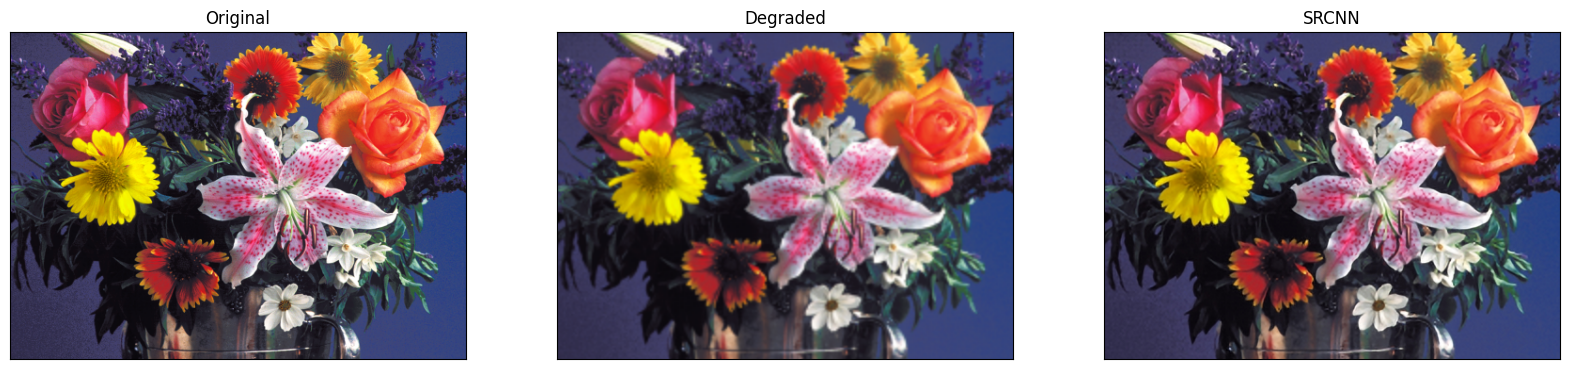

In [8]:
def modcrop(img, scale):
  tmpsz = img.shape
  sz = tmpsz[0:2]
  sz = sz - np.mod(sz, scale)
  img = img[0:sz[0], 1:sz[1]]
  return img

def shave(image, border):
  img = image[border: -border, border: -border]
  return img

def predict(image_path):
  srcnn = model()
  srcnn.load_weights("3051crop_weight_200.h5")

  path, file = os.path.split(image_path)
  degraded = cv2.imread(image_path)
  ref = cv2.imread('source/{}'.format(file))

  ref = modcrop(ref, 3)
  degraded = modcrop(degraded, 3)

  temp = cv2.cvtColor(degraded, cv2.COLOR_BGR2YCrCb)

  Y = numpy.zeros((1, temp.shape[0], temp.shape[1], 1), dtype=float)
  Y[0, :, :, 0] = temp[:, :, 0].astype(float) / 255

  pre = srcnn.predict(Y, batch_size=1)

  pre *= 255
  pre[pre[:] > 255] = 255
  pre[pre[:] < 0] = 0
  pre = pre.astype(np.uint8)

  temp = shave(temp, 6)
  temp[:, :, 0] = pre[0, :, :, 0]
  output = cv2.cvtColor(temp, cv2.COLOR_YCrCb2BGR)

  ref = shave(ref.astype(np.uint8), 6)
  degraded = shave(degraded.astype(np.uint8), 6)

  scores = []
  scores.append(compare_images(degraded,ref))
  scores.append(compare_images(output,ref))

  return ref, degraded, output, scores


ref, degraded, output, scores = predict('images/flowers.bmp')

print('Degraded Image: \nPSNR: {}\nMSE: {}\nSSIM: {}\n'.format(scores[0][0], scores[0][1], scores[0][2]))
print('Reconstructed Image: \nPSNR: {}\nMSE: {}\nSSIM: {}\n'.format(scores[1][0], scores[1][1], scores[1][2]))

# display images as subplots
fig, axs = plt.subplots(1, 3, figsize=(20, 8))
axs[0].imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
axs[0].set_title('Original')
axs[1].imshow(cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB))
axs[1].set_title('Degraded')
axs[2].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
axs[2].set_title('SRCNN')

# remove the x and y ticks
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])


In [ ]:
# Performing Super Resolution using our SRCNN model on all images (degraded)

for file in os.listdir('images'):
  try:
    ref, degraded, output, scores = predict('images/{}'.format(file))
  except:
    continue


  # display images as subplots
  fig, axs = plt.subplots(1, 3, figsize=(20, 8))
  axs[0].imshow(cv2.cvtColor(ref, cv2.COLOR_BGR2RGB))
  axs[0].set_title('Original')
  axs[1].imshow(cv2.cvtColor(degraded, cv2.COLOR_BGR2RGB))
  axs[1].set_title('Degraded')
  axs[1].set(xlabel = 'PSNR: {}\nMSE: {} \nSSIM: {}'.format(scores[0][0], scores[0][1], scores[0][2]))
  axs[2].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
  axs[2].set_title('SRCNN')
  axs[2].set(xlabel = 'PSNR: {} \nMSE: {} \nSSIM: {}'.format(scores[1][0], scores[1][1], scores[1][2]))

  for ax in axs:
      ax.set_xticks([])
      ax.set_yticks([])

  print('Saving {}'.format(file))
  fig.savefig('output/{}.png'.format(os.path.splitext(file)[0]))
plt.close()

1/1 ━━━━━━━━━━━━━━━━━━━━ 462s 462s/step
Saving baboon.bmp
1/1 ━━━━━━━━━━━━━━━━━━━━ 502s 502s/step
Saving baby_GT.bmp
1/1 ━━━━━━━━━━━━━━━━━━━━ 745s 745s/step
Saving barbara.bmp
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Saving bird_GT.bmp
